In [1]:
import sys
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import matplotlib.pyplot as plt

# Project root for src imports
_cwd = Path(".").resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = Path("/mnt/ssd/LaCie/dcase2020_task2/dcase2020_task2_dev_dataset")
CKPT_DIR = PROJECT_ROOT / "checkpoints"
MACHINE_TYPE = "slider"
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Stage 1 checkpoint (multi-type or fan-only)
STAGE1_CKPT = CKPT_DIR / "stage1" / "ToyCar+ToyConveyor+fan+pump+slider+valve" / "checkpoints_trainandtest_emb128_64_hid256_128_fine1024_coarse512_iter20000_bs256_stage1_ToyCar+ToyConveyor+fan+pump+slider+valve_best.pt"
if not STAGE1_CKPT.exists():
    STAGE1_CKPT = CKPT_DIR / "stage1" / MACHINE_TYPE / f"stage1_{MACHINE_TYPE}_best.pt"

print(f"Device: {DEVICE}")
print(f"Stage1 checkpoint: {STAGE1_CKPT}")
print(f"Data path: {DATA_PATH}")

Device: cpu
Stage1 checkpoint: /home/lucash/Documents/NTUST/Research/papers/semantic-communication-networks/audDSR/checkpoints/stage1/ToyCar+ToyConveyor+fan+pump+slider+valve/checkpoints_trainandtest_emb128_64_hid256_128_fine1024_coarse512_iter20000_bs256_stage1_ToyCar+ToyConveyor+fan+pump+slider+valve_best.pt
Data path: /mnt/ssd/LaCie/dcase2020_task2/dcase2020_task2_dev_dataset


/home/lucash/micromamba/envs/audio_ml/lib/python3.11/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647348947/work/c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
from src.data.dataset import DCASE2020Task2LogMelDataset, DCASE2020Task2TestDataset
from src.models.vq_vae.autoencoders import VQ_VAE_2Layer
from src.utils.checkpoint_compat import migrate_vq_vae_state_dict

ckpt = torch.load(STAGE1_CKPT, map_location="cpu", weights_only=True)

n_mels, T = 128, 320
test_ds = DCASE2020Task2TestDataset(
    root=str(DATA_PATH),
    machine_type=MACHINE_TYPE,
    target_T=T,
)

num_embeddings_coarse = ckpt["num_embeddings_coarse"]
num_embeddings_fine = ckpt["num_embeddings_fine"]
embedding_dim_coarse = ckpt["embedding_dim_coarse"]
embedding_dim_fine = ckpt["embedding_dim_fine"]
hidden_channels_coarse = ckpt["hidden_channels_coarse"]
hidden_channels_fine = ckpt["hidden_channels_fine"]
num_residual_layers = ckpt["num_residual_layers"]

vq_vae = VQ_VAE_2Layer(
    hidden_channels=(hidden_channels_coarse, hidden_channels_fine),
    num_residual_layers=num_residual_layers,
    num_embeddings=(num_embeddings_coarse, num_embeddings_fine),
    embedding_dim=(embedding_dim_coarse, embedding_dim_fine),
    commitment_cost=0.25,
    decay=0.95,
)
state = dict(ckpt["model_state_dict"])
migrate_vq_vae_state_dict(state)
vq_vae.load_state_dict(state)
vq_vae = vq_vae.eval().to(DEVICE)

print(f"n_mels={n_mels}, T={T}")
print(f"Test clips: {len(test_ds)}")

DCASE2020Task2TestDataset: slider | 1290 clips | IDs: ['id_00', 'id_02', 'id_04', 'id_06']
n_mels=128, T=320
Test clips: 1290


In [3]:
grouped = defaultdict(lambda: {0: [], 1: []})
for idx in range(len(test_ds)):
    spec, label, machine_id = test_ds[idx]
    if spec.dim() == 3:
        spec = spec.unsqueeze(0)
    grouped[machine_id][label].append((spec, idx))

for mid in sorted(grouped.keys()):
    n_norm = len(grouped[mid][0])
    n_anom = len(grouped[mid][1])
    print(f"{mid}: normal={n_norm}, anomaly={n_anom}")

id_00: normal=100, anomaly=356
id_02: normal=100, anomaly=267
id_04: normal=100, anomaly=178
id_06: normal=100, anomaly=89


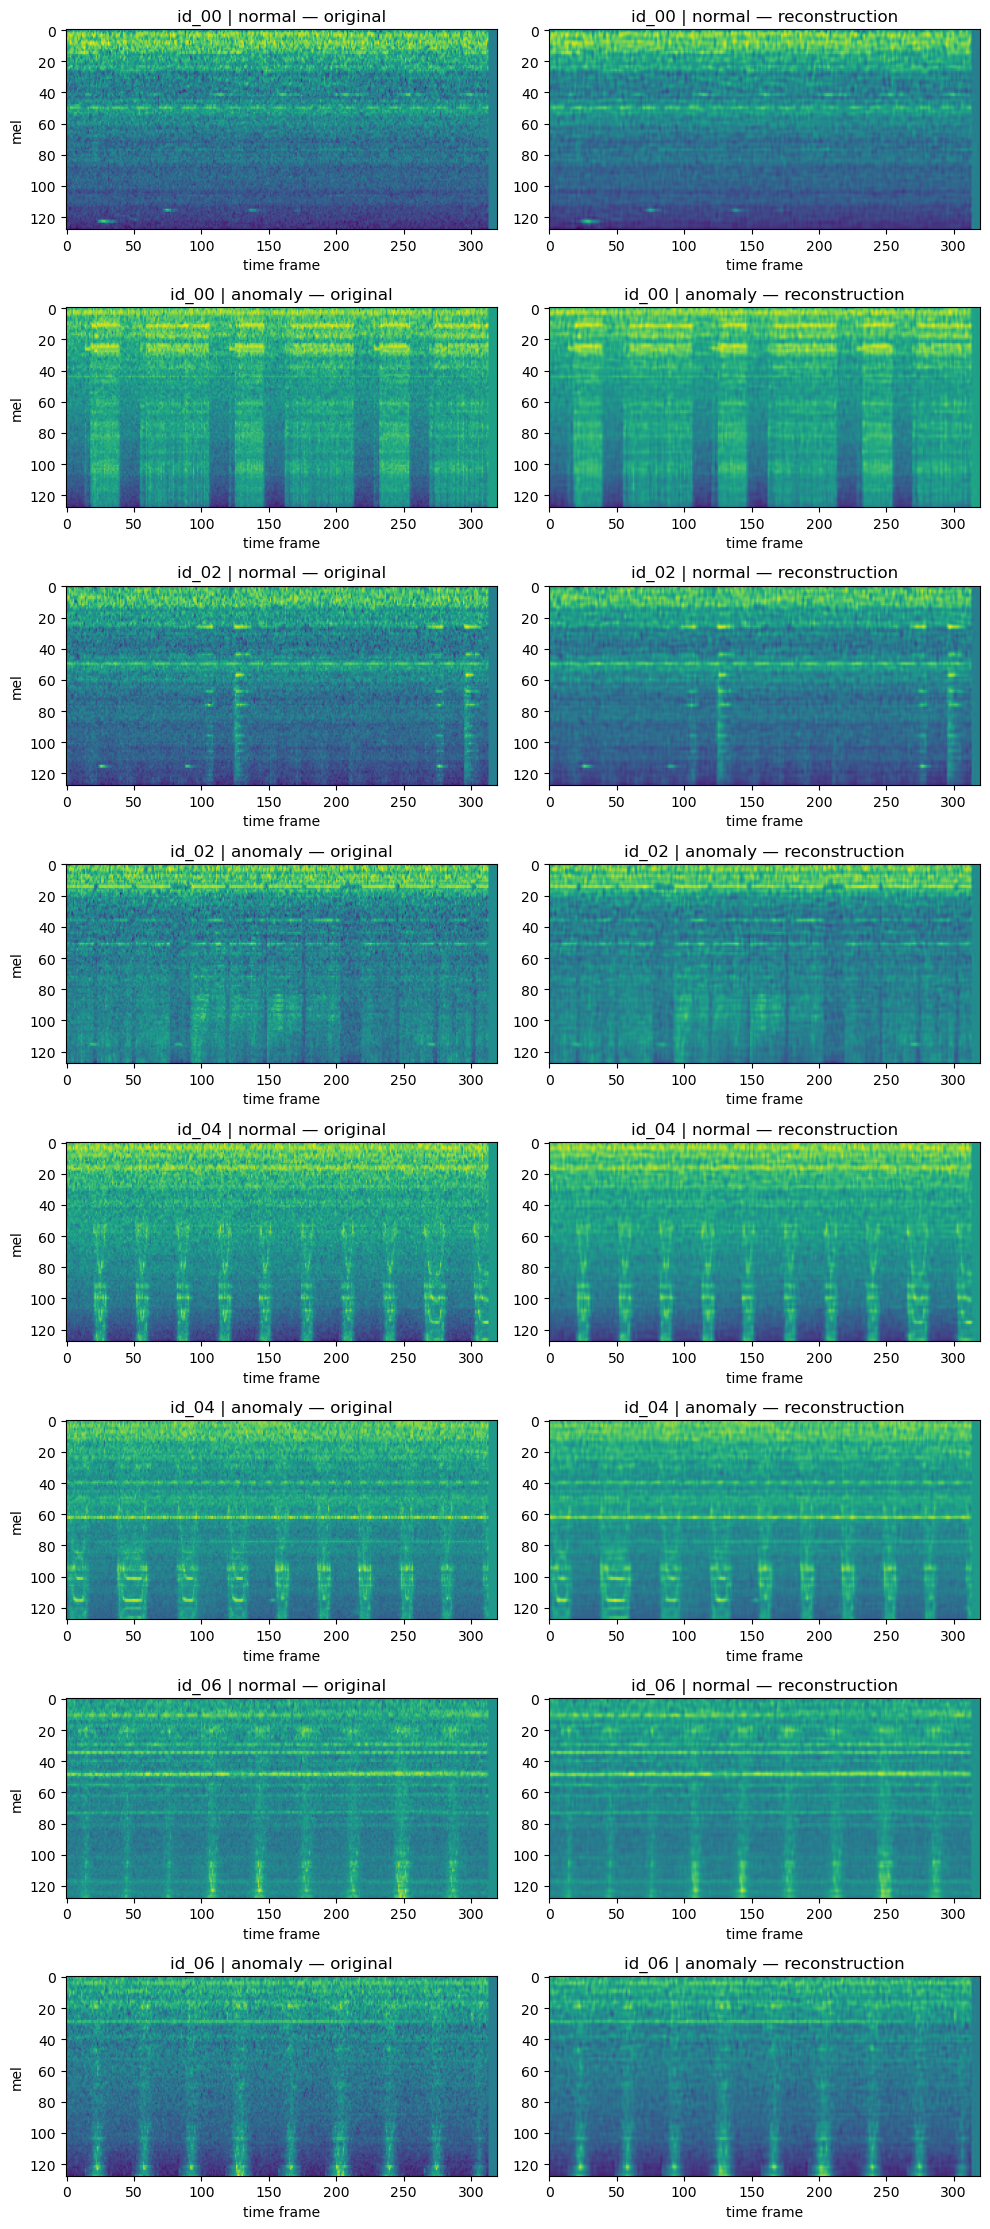

In [4]:
# One spectrogram per (machine_id, label): 4 machines × 2 labels = 8 spectrograms
label_names = {0: "normal", 1: "anomaly"}

samples = []
for mid in sorted(grouped.keys()):
    for lab in (0, 1):
        bucket = grouped[mid][lab]
        if not bucket:
            print(f"skip: no samples for machine_id={mid}, label={lab}")
            continue
        spec, idx = bucket[0]
        samples.append((mid, lab, spec, idx))

if len(samples) != 8:
    print(f"warning: expected 8 spectrograms, got {len(samples)}")


def _to_batch(x: torch.Tensor) -> torch.Tensor:
    if x.dim() == 3:
        x = x.unsqueeze(0)
    return x.to(DEVICE)


n = len(samples)
fig, axes = plt.subplots(n, 2, figsize=(10, 2.8 * max(n, 1)))
if n == 1:
    axes = np.array([axes])

for row, (mid, lab, spec, idx) in enumerate(samples):
    x = _to_batch(spec)
    with torch.no_grad():
        _, _, recon, *_ = vq_vae(x)
    orig_np = x[0, 0].cpu().numpy()
    recon_np = recon[0, 0].cpu().numpy()
    vmin = float(min(orig_np.min(), recon_np.min()))
    vmax = float(max(orig_np.max(), recon_np.max()))
    ax0, ax1 = axes[row, 0], axes[row, 1]
    ax0.imshow(orig_np, aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
    ax0.set_title(f"{mid} | {label_names[lab]} — original")
    ax0.set_ylabel("mel")
    ax1.imshow(recon_np, aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
    ax1.set_title(f"{mid} | {label_names[lab]} — reconstruction")

for ax in axes.ravel():
    ax.set_xlabel("time frame")

plt.tight_layout()
plt.show()

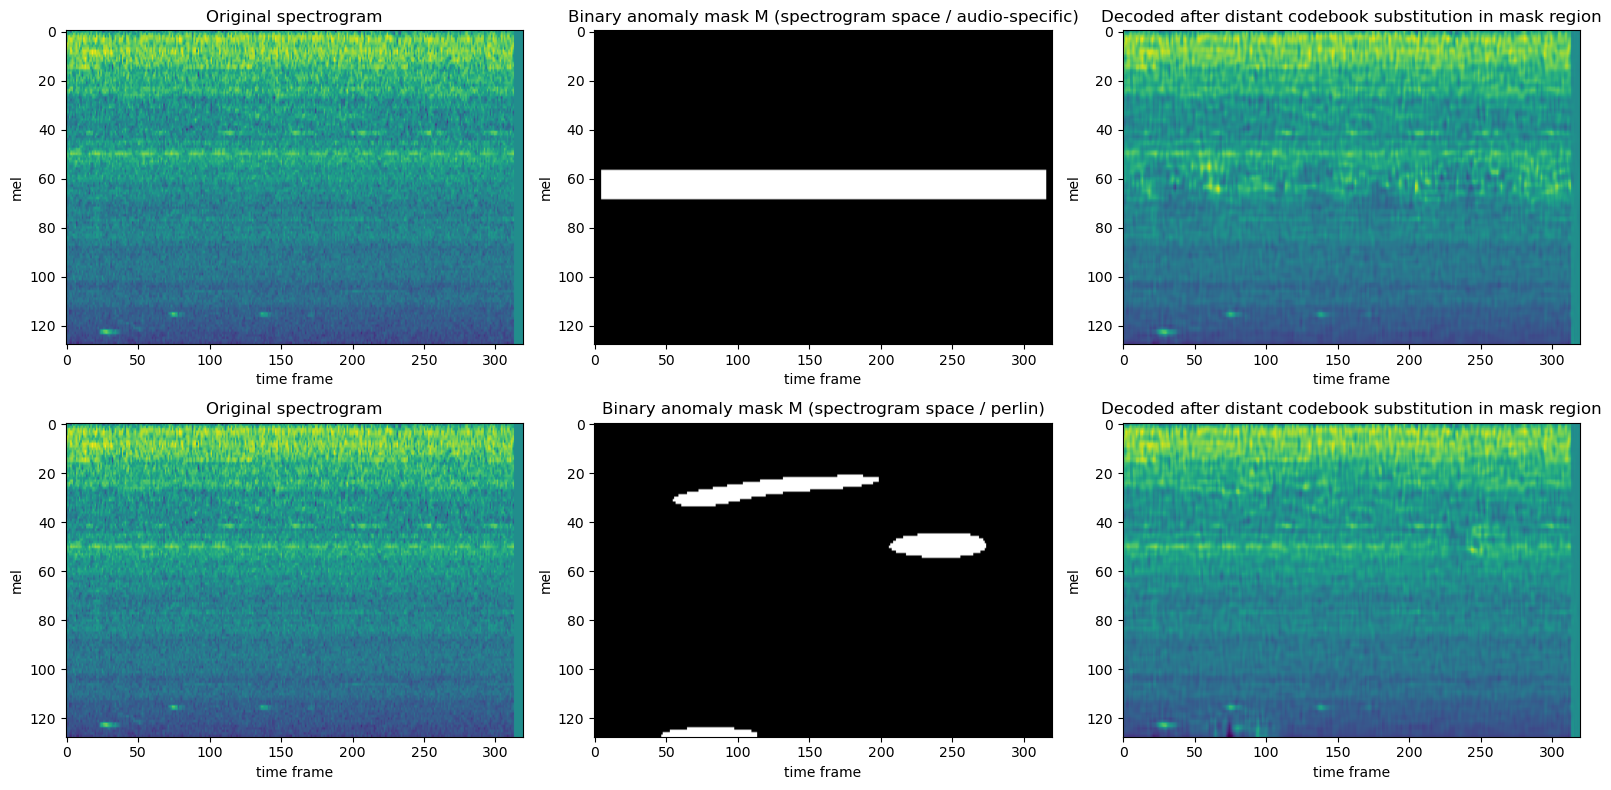

In [13]:
import torch.nn.functional as F

from src.utils.anomalies.anomaly_map import AnomalyMapGenerator
from src.utils.anomalies.anomaly_generation import generate_fake_anomalies_uniform, generate_fake_anomalies_distant


def _match_mask_size(mask: torch.Tensor, target: tuple[int, int]) -> torch.Tensor:
    """Pad or crop mask to target (H, W); same as sDSR training."""
    H, W = target
    _, _, h, w = mask.shape
    if h < H or w < W:
        mask = F.pad(mask, (0, max(0, W - w), 0, max(0, H - h)), value=0.0)
    if mask.shape[2] > H or mask.shape[3] > W:
        mask = mask[:, :, :H, :W].contiguous()
    return mask


def project_spec_mask_to_latents(
    M: torch.Tensor,
    q_fine: torch.Tensor,
    q_coarse: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Resize spectrogram-space mask to fine/coarse latent grids (avg-pool + trim/pad)."""
    M_float = M.float()
    H_spec, W_spec = M_float.shape[2], M_float.shape[3]
    H_fine, W_fine = q_fine.shape[2], q_fine.shape[3]
    H_coarse, W_coarse = q_coarse.shape[2], q_coarse.shape[3]
    stride_fine = (max(1, H_spec // H_fine), max(1, W_spec // W_fine))
    stride_coarse = (max(1, H_spec // H_coarse), max(1, W_spec // W_coarse))
    M_fine = F.avg_pool2d(M_float, kernel_size=stride_fine, stride=stride_fine)
    M_coarse = F.avg_pool2d(M_float, kernel_size=stride_coarse, stride=stride_coarse)
    if M_fine.shape[2] != H_fine or M_fine.shape[3] != W_fine:
        M_fine = _match_mask_size(M_fine, (H_fine, W_fine))
    if M_coarse.shape[2] != H_coarse or M_coarse.shape[3] != W_coarse:
        M_coarse = _match_mask_size(M_coarse, (H_coarse, W_coarse))
    return M_fine, M_coarse


n_mels, T = 128, 320
mask_gen_audio = AnomalyMapGenerator(
    strategy="audio_specific",
    spectrogram_shape=(n_mels, T),
    n_mels=n_mels,
    T=T,
)

mask_gen_perlin = AnomalyMapGenerator(
    strategy="perlin",
    spectrogram_shape=(n_mels, T),
    n_mels=n_mels,
    T=T,
)

# One clean clip (first normal sample for the first machine_id)
first_mid = sorted(grouped.keys())[0]
spec, _idx = grouped[first_mid][0][0]


def _to_batch(x: torch.Tensor) -> torch.Tensor:
    if x.dim() == 3:
        x = x.unsqueeze(0)
    return x.to(DEVICE)


x = _to_batch(spec)
with torch.no_grad():
    M_audio = mask_gen_audio.generate(1, DEVICE, force_anomaly=True)
    M_perlin = mask_gen_perlin.generate(1, DEVICE, force_anomaly=True)
    q_fine, q_coarse, z_fine, z_coarse = vq_vae.encode_with_prequant(x)
    M_fine_audio, M_coarse_audio = project_spec_mask_to_latents(M_audio, q_fine, q_coarse)
    M_fine_perlin, M_coarse_perlin = project_spec_mask_to_latents(M_perlin, q_fine, q_coarse)
    cb_fine = vq_vae._vq_fine._embedding.weight
    cb_coarse = vq_vae._vq_coarse._embedding.weight
    q_fine_a_audio = generate_fake_anomalies_distant(z_fine, q_fine, cb_fine, M_fine_audio, strength=0.99)
    q_coarse_a_audio = generate_fake_anomalies_distant(z_coarse, q_coarse, cb_coarse, M_coarse_audio, strength=0.99)
    x_synthetic_audio = vq_vae.decode_general(q_fine_a_audio, q_coarse_a_audio)
    q_fine_a_perlin = generate_fake_anomalies_distant(z_fine, q_fine, cb_fine, M_fine_perlin, strength=0.99)
    q_coarse_a_perlin = generate_fake_anomalies_distant(z_coarse, q_coarse, cb_coarse, M_coarse_perlin, strength=0.99)
    x_synthetic_perlin = vq_vae.decode_general(q_fine_a_perlin, q_coarse_a_perlin)

orig = x[0, 0].cpu().numpy()
mask_np_audio = M_audio[0, 0].cpu().numpy()
mask_np_perlin = M_perlin[0, 0].cpu().numpy()
syn_audio = x_synthetic_audio[0, 0].cpu().numpy()
syn_perlin = x_synthetic_perlin[0, 0].cpu().numpy()
vmin = float(min(orig.min(), syn_audio.min(), syn_perlin.min()))
vmax = float(max(orig.max(), syn_audio.max(), syn_perlin.max()))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()
axes[0].imshow(orig, aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_title("Original spectrogram")
axes[1].imshow(mask_np_audio, aspect="auto", cmap="gray", vmin=0.0, vmax=1.0)
axes[1].set_title("Binary anomaly mask M (spectrogram space / audio-specific)")
axes[2].imshow(syn_audio, aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
axes[2].set_title("Decoded after distant codebook substitution in mask region")
axes[3].imshow(orig, aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
axes[3].set_title("Original spectrogram")
axes[4].imshow(mask_np_perlin, aspect="auto", cmap="gray", vmin=0.0, vmax=1.0)
axes[4].set_title("Binary anomaly mask M (spectrogram space / perlin)")
axes[5].imshow(syn_perlin, aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
axes[5].set_title("Decoded after distant codebook substitution in mask region")
for ax in axes:
    ax.set_xlabel("time frame")
    ax.set_ylabel("mel")
plt.tight_layout()
plt.show()